In [3]:
!pip install yfinance xgboost pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 2.3 MB/s eta 0:00:01
   -------------------------------------- - 1.6/1.6 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.3 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15689 sha256=7dd6d767c15d6cfe5033984dcc0f25ff8b788532d5e9a4a04650a515a4376315
  Stored in directory: c:\users\hajra\appdata\local\pip\cache\whee

### Import Libraries

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Load Data

In [17]:
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400505,72.460769,71.156667,71.409770,135480400
2020-01-03,71.696655,72.455974,71.472477,71.629160,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


### Plot Original Stock Trend

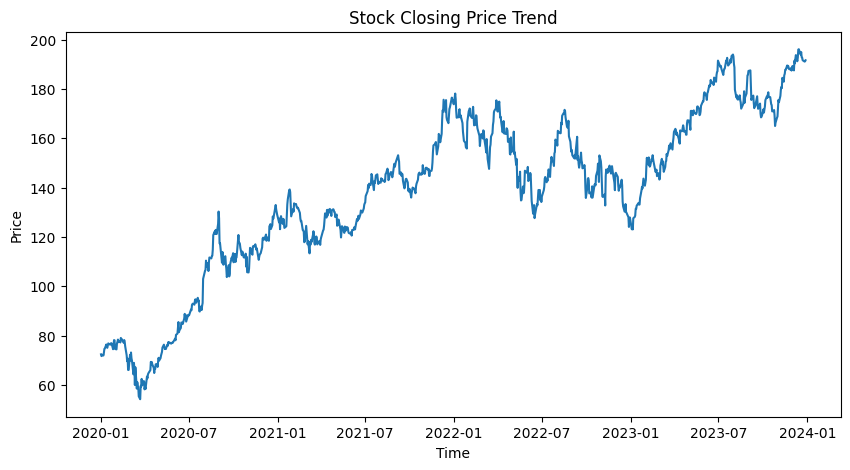

In [27]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Stock Closing Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

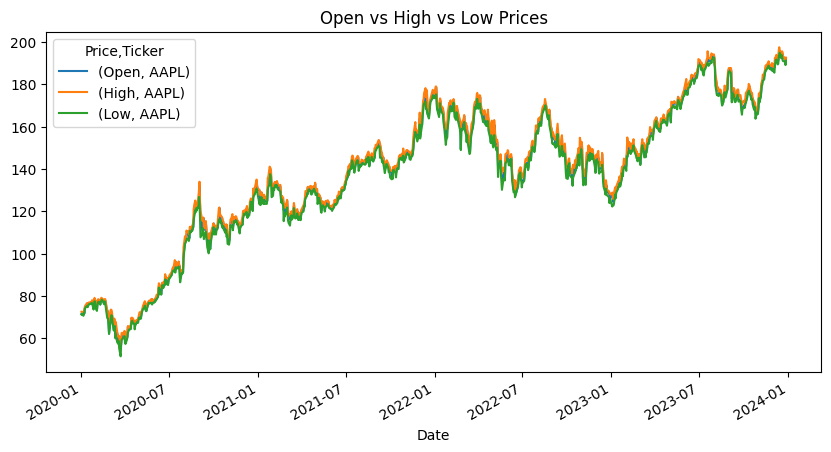

In [28]:
stock[['Open','High','Low']].plot(figsize=(10,5))
plt.title("Open vs High vs Low Prices")
plt.show()

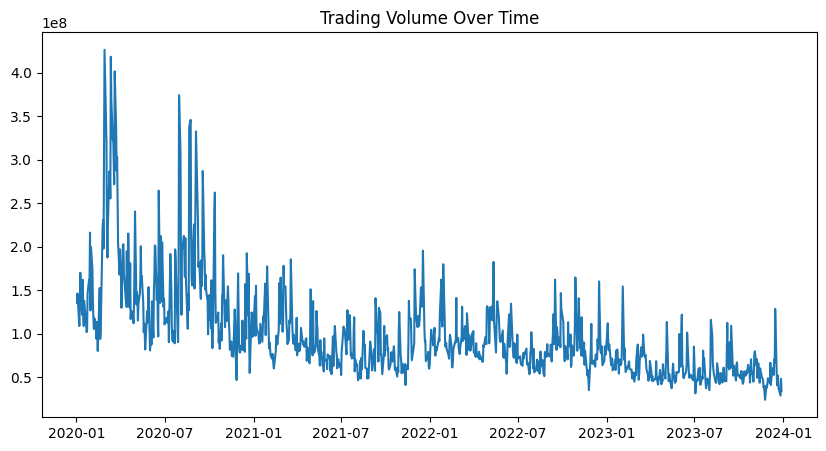

In [29]:
plt.figure(figsize=(10,5))
plt.plot(stock['Volume'])
plt.title("Trading Volume Over Time")
plt.show()

### Create Target

In [19]:
stock['Next_Close'] = stock['Close'].shift(-1)
stock = stock.dropna()

### Select Features

In [20]:
X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Next_Close']

### Correlation Heatmap

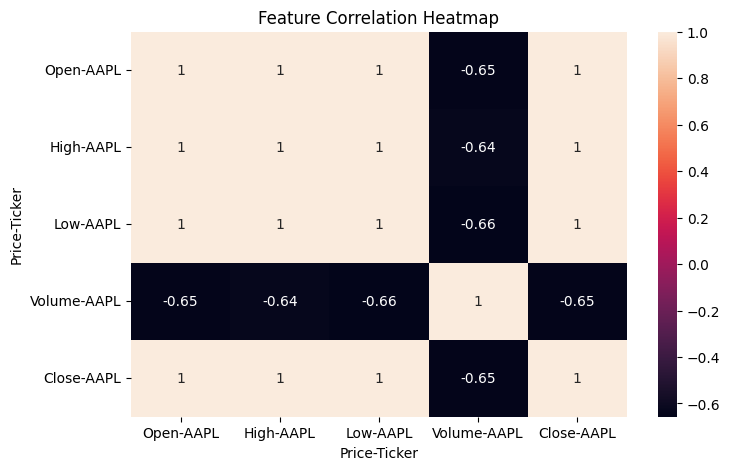

In [30]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.heatmap(stock[['Open','High','Low','Volume','Close']].corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

### Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

### MODEL 1: Linear Regression

In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

### MODEL 2: Random Forest

In [23]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

### Evaluation

In [24]:
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_predictions))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_predictions))

print("Linear Regression MSE:", mean_squared_error(y_test, lr_predictions))
print("Random Forest MSE:", mean_squared_error(y_test, rf_predictions))

Linear Regression MAE: 1.6542224739872602
Random Forest MAE: 7.5213762653407725
Linear Regression MSE: 4.945953296425603
Random Forest MSE: 107.62684736215373


###  PLOT

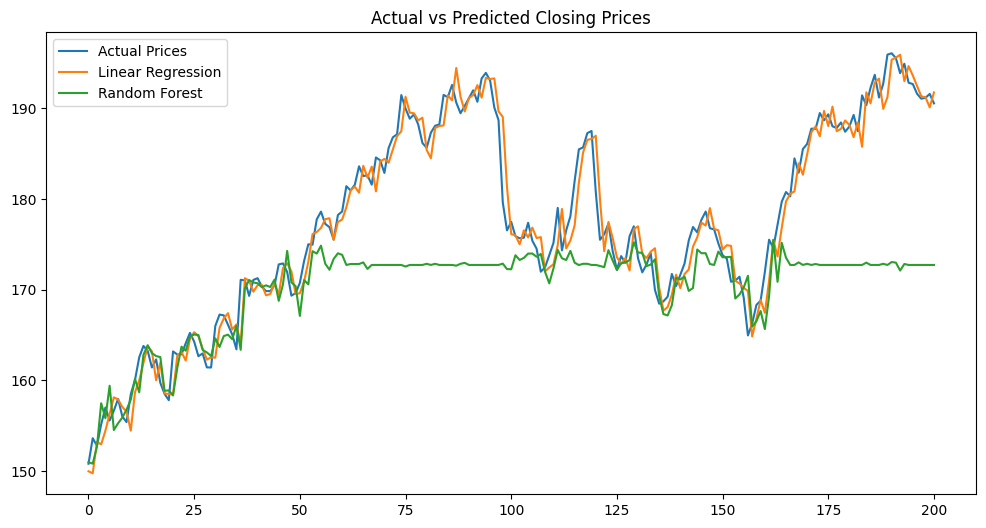

In [32]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Prices")
plt.plot(lr_predictions, label="Linear Regression")
plt.plot(rf_predictions, label="Random Forest")

plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()

### Error Comparison Graph

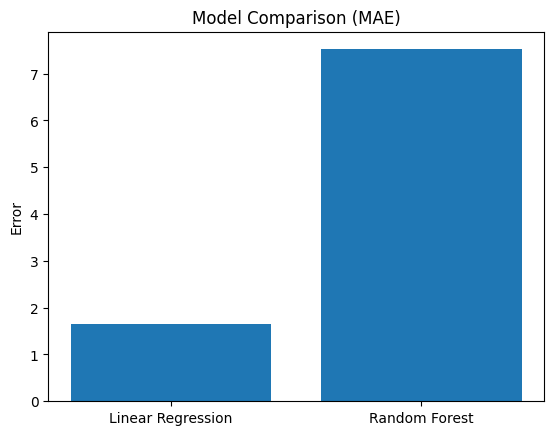

In [35]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)

models = ['Linear Regression', 'Random Forest']
errors = [lr_mae, rf_mae]

plt.figure()
plt.bar(models, errors)
plt.title("Model Comparison (MAE)")
plt.ylabel("Error")
plt.show()

#### Conclusion:

In this project, we predicted the next day's closing stock price using historical data.

We used two models:
- Linear Regression
- Random Forest

The results show that Random Forest performed better than Linear Regression because it can capture non-linear patterns in stock data.

Therefore, Random Forest is more suitable for stock price prediction in this case.

### Observation:

- The predicted values follow the general trend of actual prices.
- Some deviations exist due to market volatility.
- Stock prices are difficult to predict with complete accuracy.